In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [2]:
df = pd.read_csv('/home/goverdovskiy/Backblaze_ML_Ops/Artifacts/Exp_150/results.csv', index_col=False)
df.head()

,quantile,t_point,agg_samples,agg_method,agg_weight,model_id,quantile_mode,ci,ibs,ibs_bal
0,5,225.0,1,DDH,-1,0_DDH,failures_only,0.513149,0.259973,0.259949
1,5,225.0,5,DDH,-1,0_DDH,failures_only,0.532207,0.289510,0.229239
2,5,225.0,10,DDH,-1,0_DDH,failures_only,0.540568,0.295975,0.313347
3,25,544.0,1,DDH,-1,0_DDH,failures_only,0.486077,0.232463,0.230396
4,25,544.0,5,DDH,-1,0_DDH,failures_only,0.581352,0.272766,0.240477


In [3]:
def plot_agg(df: pd.DataFrame, agg_method: str, agg_weight: float, model_id: str = None):
    """
    Plot CI and IBS metrics by quantile for different agg_samples values.

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe (results.csv).
    agg_method : str
        Aggregation method to filter by (e.g. 'n_dist', 'geom').
    agg_weight : float
        Aggregation weight to filter by (e.g. 0.1, 0.5, 0.9).
    model_id : str, optional
        If provided, filter by this model_id. Otherwise average over all models.
    """
    # Exclude 'mean' pseudo-quantile
    data = df[df['quantile'] != 'mean'].copy()
    data['quantile'] = data['quantile'].astype(int)

    # Filter by parameters
    data = data[data['agg_method'] == agg_method]
    data = data[data['agg_weight'] == agg_weight]
    if model_id is not None:
        data = data[data['model_id'] == model_id]

    if data.empty:
        print("No data matching the given filters.")
        return

    samples_values = sorted(data['agg_samples'].unique())

    # Color palette for agg_samples lines
    colors = {s: c for s, c in zip(samples_values, ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple'])}

    enable_ibs_bal = 'ibs_bal' in data.columns    

    fig, ax = plt.subplots(2 + enable_ibs_bal, 1, figsize=(9, 8), sharex=True)
    ax_ci = ax[0]
    ax_ibs = ax[1]
    if enable_ibs_bal:
        ax_ibs_bal = ax[2]

    for samples in samples_values:
        subset = data[data['agg_samples'] == samples]
        grouped = subset.groupby('quantile')[['ci', 'ibs', 'ibs_bal']].mean().sort_index()

        ax_ci.plot(grouped.index, grouped['ci'],
                   color=colors[samples], marker='o', label=f'agg_samples={samples}')
        ax_ibs.plot(grouped.index, grouped['ibs'],
                    color=colors[samples], marker='o', label=f'agg_samples={samples}')
        if enable_ibs_bal:
            ax_ibs_bal.plot(grouped.index, grouped['ibs_bal'],
                    color=colors[samples], marker='o', label=f'agg_samples={samples}')

    ax_ci.set_ylabel('CI')
    ax_ci.set_title(f'CI  |  method={agg_method}, weight={agg_weight}, model={model_id or "all"}')
    ax_ci.legend()
    ax_ci.grid(True, linestyle='--', alpha=0.5)

    ax_ibs.set_ylabel('IBS')
    ax_ibs.set_xlabel('Quantile')
    ax_ibs.set_title(f'IBS  |  method={agg_method}, weight={agg_weight}, model={model_id or "all"}')
    ax_ibs.legend()
    ax_ibs.grid(True, linestyle='--', alpha=0.5)

    ax_ibs.set_xticks(sorted(data['quantile'].unique()))

    if enable_ibs_bal:
        ax_ibs_bal.set_ylabel('IBS BAL')
        ax_ibs_bal.set_xlabel('Quantile')
        ax_ibs_bal.set_title(f'IBS BAL |  method={agg_method}, weight={agg_weight}, model={model_id or "all"}')
        ax_ibs_bal.legend()
        ax_ibs_bal.grid(True, linestyle='--', alpha=0.5)

        ax_ibs_bal.set_xticks(sorted(data['quantile'].unique()))

    plt.tight_layout()
    plt.show()

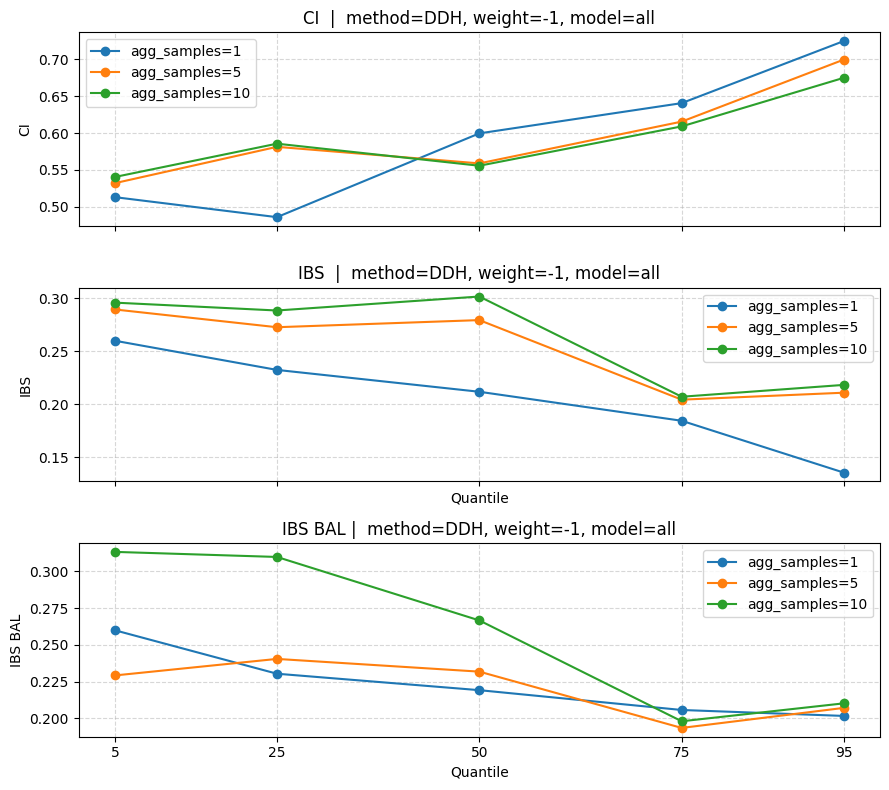

In [4]:
plot_agg(df, agg_method='DDH', agg_weight=-1)

In [5]:
# n_dist, weight=0.9 — all models
plot_agg(df, agg_method='n_dist', agg_weight=0.9)

No data matching the given filters.


In [6]:
# n_dist, weight=0.1 — all models
plot_agg(df, agg_method='n_dist', agg_weight=0.1)

No data matching the given filters.


In [7]:
# geom, weight=0.9 — all models
plot_agg(df, agg_method='geom', agg_weight=0.9)

No data matching the given filters.


In [8]:
# geom, weight=0.9 — all models
plot_agg(df, agg_method='geom', agg_weight=0.1)

No data matching the given filters.


In [9]:
# n_dist, weight=0.5, filtered by specific model
plot_agg(df, agg_method='n_dist', agg_weight=0.5, model_id='0_CoxTV')

No data matching the given filters.


# Исследование квантилей

In [1]:
import pandas as pd
from disk_analyzer.research.aggregation.quantile_runner import build_history_at_time, build_gt_at_time, get_quantile_time_points

/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/survivors/metrics.py:113: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def get_before(estim, wei):
/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/survivors/metrics.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argu

In [2]:
df = pd.read_parquet('/home/goverdovskiy/Backblaze_ML_Ops/Data/Preprocessed_new_data/20_-1_test_preprocessed.parquet')

In [3]:
df

,max_lifetime,smart_5_raw,smart_197_raw,smart_194_raw,smart_184_raw,smart_193_raw,smart_4_raw,capacity_bytes,smart_198_raw,smart_183_raw,...,smart_199_raw,serial_number,smart_1_raw,smart_12_raw,smart_191_raw,smart_188_raw,smart_2_raw,smart_195_raw,smart_241_raw,failure
0,694,-0.089606,-0.023664,1.058168,-0.037517,-0.151186,-0.051372,-0.007132,-0.019888,-0.030537,...,-0.050848,175PP3I9T,-0.008231,-0.337512,-0.079375,-0.055264,-0.412839,-0.017837,-0.055680,True
1,694,-0.089606,-0.023664,1.058168,-0.037517,-0.151156,-0.051372,-0.007132,-0.019888,-0.030537,...,-0.050848,175PP3I9T,-0.008231,-0.337512,-0.079375,-0.055264,-0.412839,-0.017837,-0.055680,True
2,694,-0.089606,-0.023664,1.584408,-0.037517,-0.151156,-0.051372,-0.007132,-0.019888,-0.030537,...,-0.050848,175PP3I9T,-0.008231,-0.337512,-0.079375,-0.055264,-0.412839,-0.017837,-0.055680,True
3,694,-0.089606,-0.023664,1.584408,-0.037517,-0.151156,-0.051372,-0.007132,-0.019888,-0.030537,...,-0.050848,175PP3I9T,-0.008231,-0.337512,-0.079375,-0.055264,-0.412839,-0.017837,-0.055680,True
4,694,-0.089606,-0.023664,1.759822,-0.037517,-0.151156,-0.051372,-0.007132,-0.019888,-0.030537,...,-0.050848,175PP3I9T,-0.008231,-0.337512,-0.079375,-0.055264,-0.412839,-0.017837,-0.055680,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1870274,41,-0.089606,-0.023664,-1.222209,-0.037517,-0.158760,-0.054172,-0.003910,-0.019888,-0.030537,...,-0.050848,ZJV5HVRQ,-0.004141,-0.370294,-0.079375,-0.055264,-0.412839,-0.017826,-0.063581,True
1870275,41,-0.089606,-0.023664,-1.222209,-0.037517,-0.158745,-0.054172,-0.003910,-0.019888,-0.030537,...,-0.050848,ZJV5HVRQ,-0.007115,-0.370294,-0.079375,-0.055264,-0.412839,-0.017837,-0.063457,True
1870276,41,-0.089606,-0.023664,-1.222209,-0.037517,-0.158745,-0.054172,-0.003910,-0.019888,-0.030537,...,-0.050848,ZJV5HVRQ,0.006652,-0.370294,-0.079375,-0.055264,-0.412839,-0.017786,-0.063390,True
1870277,41,-0.089606,-0.023664,-1.222209,-0.037517,-0.158729,-0.054172,-0.003910,-0.019888,-0.030537,...,-0.050848,ZJV5HVRQ,0.000125,-0.370294,-0.079375,-0.055264,-0.412839,-0.017810,-0.063245,True


In [ ]:
# import numpy as np
# quantiles = [5, 25, 50, 75, 95]
# MAX_OBS_DAY = 1600

# all_event_times = df.loc[
#             df["max_lifetime"] <= MAX_OBS_DAY,
#             "max_lifetime"
#         ]

# only_faliures_event_times = df.loc[
#             (df["failure"] == 1) & (df["max_lifetime"] <= MAX_OBS_DAY),
#             "max_lifetime"
#         ]

# print(f'Квантили по всем объектам {np.percentile(all_event_times, quantiles)}')
# print(f'Квантили по терминальным {np.percentile(only_faliures_event_times, quantiles)}')


Квантили по всем объектам [ 544. 1126. 1301. 1521. 1583.]
Квантили по терминальным [ 203.  545.  877. 1256. 1497.]


In [5]:
quantiles = [5, 25, 50, 75, 95]
t_points = get_quantile_time_points(df, quantiles, mode='failures_only')

Квантиль: 5, t: 225.0
Число наблюдений: 986
Число терминальных дисков: 954
Число цензурированных дисков: 32
Число цензурированных наблюдений: 32
Количество уникальных дисков: 986
Среднее число наблюдений на диск: 1.0
------------------------------


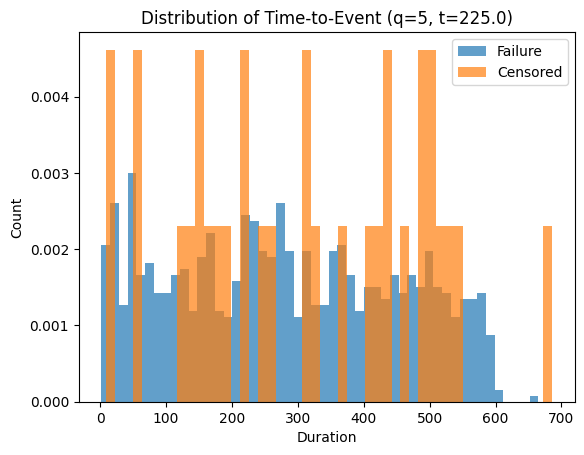

Квантиль: 25, t: 544.0
Число наблюдений: 695
Число терминальных дисков: 606
Число цензурированных дисков: 89
Число цензурированных наблюдений: 89
Количество уникальных дисков: 695
Среднее число наблюдений на диск: 1.0
------------------------------


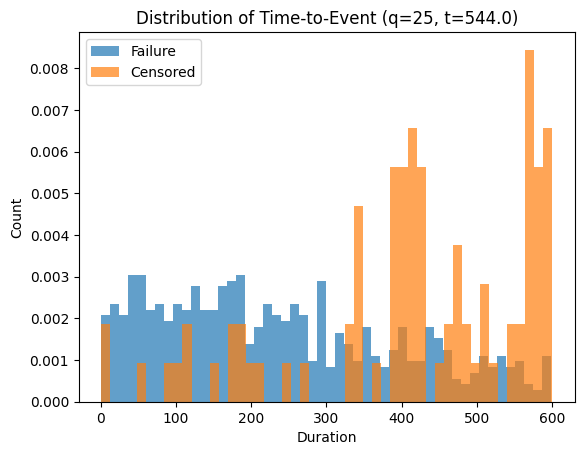

Квантиль: 50, t: 824.0
Число наблюдений: 635
Число терминальных дисков: 392
Число цензурированных дисков: 243
Число цензурированных наблюдений: 243
Количество уникальных дисков: 635
Среднее число наблюдений на диск: 1.0
------------------------------


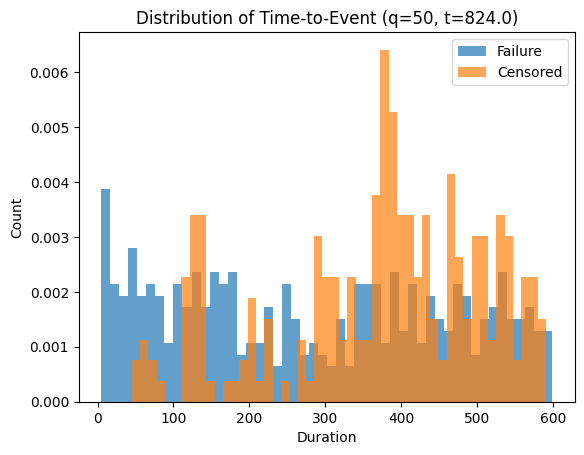

Квантиль: 75, t: 1217.0
Число наблюдений: 634
Число терминальных дисков: 197
Число цензурированных дисков: 437
Число цензурированных наблюдений: 437
Количество уникальных дисков: 634
Среднее число наблюдений на диск: 1.0
------------------------------


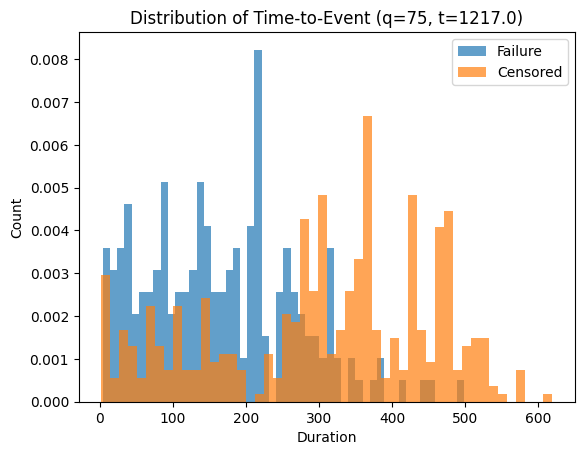

Квантиль: 95, t: 1474.0
Число наблюдений: 343
Число терминальных дисков: 37
Число цензурированных дисков: 306
Число цензурированных наблюдений: 306
Количество уникальных дисков: 343
Среднее число наблюдений на диск: 1.0
------------------------------


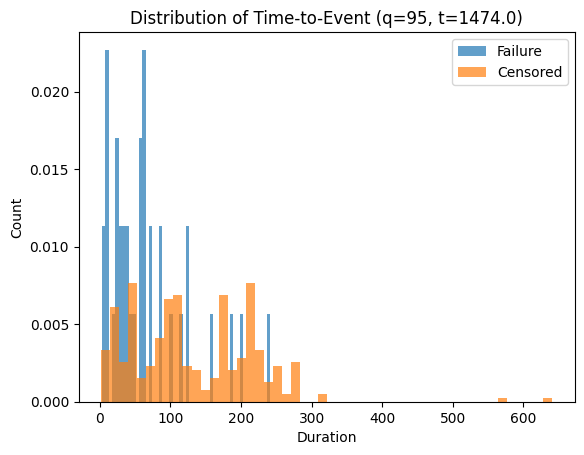

In [7]:
import matplotlib.pyplot as plt

for q, t_point in zip(quantiles, t_points):
    histories_dict = build_history_at_time(df, t_point, [1])
    df_cur = histories_dict[1]
    X_gt = build_gt_at_time(df_cur)
    sep = '-' * 30
    
    print(f'Квантиль: {q}, t: {t_point}')
    # print(sep)
    
    terminal = df_cur.groupby("serial_number")['failure'].max().sum()
    
    print(f'Число наблюдений: {df_cur.shape[0]}')
    print(f'Число терминальных дисков: {terminal}')
    print(f'Число цензурированных дисков: {len(df_cur["serial_number"].unique()) - terminal}')
    print(f'Число цензурированных наблюдений: {df_cur.shape[0] - terminal}')
    # print(sep)
    print(f'Количество уникальных дисков: {len(df_cur["serial_number"].unique())}')
    print(f'Среднее число наблюдений на диск: {df_cur.groupby("serial_number").size().mean()}')
    print(sep)
    
    # === График распределения времени до события ===
    plt.figure()
    
    event_times = X_gt[X_gt['failure'] == 1]['duration']
    censored_times = X_gt[X_gt['failure'] == 0]['duration']
    
    plt.hist(event_times, bins=50, alpha=0.7, label='Failure', density=True)
    plt.hist(censored_times, bins=50, alpha=0.7, label='Censored',density=True)
    
    plt.legend()
    plt.title(f'Distribution of Time-to-Event (q={q}, t={t_point})')
    plt.xlabel('Duration')
    plt.ylabel('Count')
    
    plt.show()

In [10]:
df[df['failure']]['max_lifetime'].max()

1715